# 01 — Data Understanding

**AttriSense · Employee Attrition Prediction & Analytics System**

---

## Project Introduction

AttriSense predicts employee attrition and surfaces HR analytics from workforce data. Before any cleaning, feature engineering, or modeling, we need a clear picture of what the raw dataset contains.

This notebook performs **data understanding only**. No preprocessing, imputation, encoding, or row/column removal is applied here. Every figure and table is computed directly from the raw CSV.

**Dataset:** IBM HR Analytics Employee Attrition (`WA_Fn-UseC_-HR-Employee-Attrition.csv`)

**Goal of this notebook:** Document structure, quality, distributions, and column roles so later pipeline steps are informed by evidence rather than assumptions.

## Library Imports

We use Pandas for tabular inspection and Matplotlib for a single class-balance chart. The project package (`attrisense`) provides a shared loader so notebooks read from the path defined in `configs/config.yaml`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from attrisense.config import load_config
from attrisense.data import load_raw_data

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

config = load_config()
TARGET = config.target_column

## Dataset Loading

The raw file is loaded as-is. No transformations are applied at read time.

In [2]:
df = load_raw_data()
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Shape

Row and column counts establish dataset size and scope.

In [3]:
n_rows, n_cols = df.shape
print(f"Rows   : {n_rows:,}")
print(f"Columns: {n_cols}")

Rows   : 1,470
Columns: 35


## Data Types

Column dtypes determine which fields are numeric, categorical, or identifiers. This drives encoding and scaling decisions in later notebooks.

In [4]:
dtype_overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "unique_values": df.nunique(),
})
dtype_overview

,dtype,non_null_count,unique_values
Age,int64,1470,43
Attrition,str,1470,2
BusinessTravel,str,1470,3
DailyRate,int64,1470,886
Department,str,1470,3
DistanceFromHome,int64,1470,29
Education,int64,1470,5
EducationField,str,1470,6
EmployeeCount,int64,1470,1
EmployeeNumber,int64,1470,1470


## Missing Values

Missing data would require an imputation strategy. We count nulls per column across the full dataset.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_counts = missing[missing > 0]

print(f"Total missing values (all columns): {missing.sum()}")
print(f"Columns with missing values    : {len(missing_counts)}")

if missing_counts.empty:
    print("No missing values found.")
else:
    missing_counts

Total missing values (all columns): 0
Columns with missing values    : 0
No missing values found.


## Duplicates

Duplicate rows or repeated employee IDs would skew counts and leak information across splits. We check full-row duplicates and `EmployeeNumber` uniqueness separately.

In [6]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["EmployeeNumber"].duplicated().sum()

print(f"Duplicate rows          : {duplicate_rows}")
print(f"Duplicate EmployeeNumber: {duplicate_ids}")
print(f"Unique EmployeeNumber   : {df['EmployeeNumber'].nunique()}")

Duplicate rows          : 0
Duplicate EmployeeNumber: 0
Unique EmployeeNumber   : 1470


## Statistical Summary

Descriptive statistics for numeric columns: central tendency, spread, and observed min/max. Useful for spotting skew and scale differences before feature engineering.

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")

df[numeric_cols].describe().T

Numeric columns: 26


,count,mean,std,min,25%,50%,75%,max
Age,1470.00,36.92,9.14,18.00,30.00,36.00,43.00,60.00
DailyRate,1470.00,802.49,403.51,102.00,465.00,802.00,1157.00,1499.00
DistanceFromHome,1470.00,9.19,8.11,1.00,2.00,7.00,14.00,29.00
Education,1470.00,2.91,1.02,1.00,2.00,3.00,4.00,5.00
EmployeeCount,1470.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
EmployeeNumber,1470.00,1024.87,602.02,1.00,491.25,1020.50,1555.75,2068.00
EnvironmentSatisfaction,1470.00,2.72,1.09,1.00,2.00,3.00,4.00,4.00
HourlyRate,1470.00,65.89,20.33,30.00,48.00,66.00,83.75,100.00
JobInvolvement,1470.00,2.73,0.71,1.00,2.00,3.00,3.00,4.00
JobLevel,1470.00,2.06,1.11,1.00,1.00,2.00,3.00,5.00


## Categorical Summary

For each non-numeric column we report the number of distinct values and the top category frequencies. This reveals cardinality and dominant classes.

In [8]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"Categorical columns: {len(categorical_cols)}\n")

for col in categorical_cols:
    print(f"--- {col} (unique: {df[col].nunique()}) ---")
    print(df[col].value_counts())
    print()

Categorical columns: 9

--- Attrition (unique: 2) ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

--- BusinessTravel (unique: 3) ---
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

--- Department (unique: 3) ---
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

--- EducationField (unique: 6) ---
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

--- Gender (unique: 2) ---
Gender
Male      882
Female    588
Name: count, dtype: int64

--- JobRole (unique: 9) ---
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative       

## Target Distribution

`Attrition` is the prediction target. Class balance affects metric selection and whether class weighting may be needed during modeling.

           count  percent
Attrition                
No          1233    83.88
Yes          237    16.12



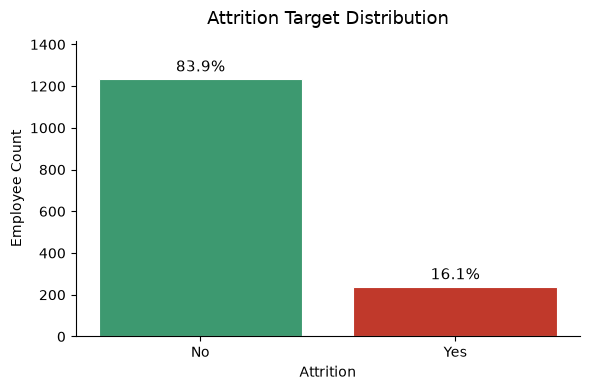

In [9]:
target_counts = df[TARGET].value_counts()
target_pct = (df[TARGET].value_counts(normalize=True) * 100).round(2)

summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_pct,
})
print(summary)
print()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#3d9970", "#c0392b"]
bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)
ax.set_title("Attrition Target Distribution", fontsize=13, pad=12)
ax.set_xlabel("Attrition")
ax.set_ylabel("Employee Count")
ax.set_ylim(0, target_counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)

for bar, pct in zip(bars, target_pct.values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

## Column Categorization

Grouping columns by role clarifies which fields are targets, identifiers, constants, and candidate features. Assignments are based on column names and the unique-value counts shown above.

In [10]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

column_groups = {
    "Target": [TARGET],
    "Identifier": ["EmployeeNumber"],
    "Constant (single value)": constant_cols,
    "Demographics": [
        "Age", "Gender", "MaritalStatus", "DistanceFromHome",
        "Education", "EducationField",
    ],
    "Job & Role": [
        "Department", "JobRole", "JobLevel", "JobInvolvement",
        "BusinessTravel", "OverTime",
    ],
    "Compensation": [
        "MonthlyIncome", "DailyRate", "HourlyRate", "MonthlyRate",
        "PercentSalaryHike", "StockOptionLevel",
    ],
    "Tenure": [
        "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
        "YearsSinceLastPromotion", "YearsWithCurrManager",
        "NumCompaniesWorked",
    ],
    "Satisfaction & Performance": [
        "EnvironmentSatisfaction", "JobSatisfaction",
        "RelationshipSatisfaction", "WorkLifeBalance",
        "PerformanceRating",
    ],
    "Training": ["TrainingTimesLastYear"],
}

rows = []
for group, cols in column_groups.items():
    for col in cols:
        if col in df.columns:
            rows.append({
                "group": group,
                "column": col,
                "dtype": str(df[col].dtype),
                "unique_values": df[col].nunique(),
            })

column_map = pd.DataFrame(rows)
column_map

,group,column,dtype,unique_values
0,Target,Attrition,str,2
1,Identifier,EmployeeNumber,int64,1470
2,Constant (single value),EmployeeCount,int64,1
3,Constant (single value),Over18,str,1
4,Constant (single value),StandardHours,int64,1
5,Demographics,Age,int64,43
6,Demographics,Gender,str,2
7,Demographics,MaritalStatus,str,3
8,Demographics,DistanceFromHome,int64,29
9,Demographics,Education,int64,5


## Initial Observations

The points below are derived from the outputs in this notebook. Re-run all cells to refresh these numbers if the source file changes.

In [11]:
# Compute observation metrics from the loaded dataset (no preprocessing).
obs_rows = df.shape[0]
obs_cols = df.shape[1]
obs_missing = int(df.isna().sum().sum())
obs_dup_rows = int(df.duplicated().sum())
obs_dup_ids = int(df["EmployeeNumber"].duplicated().sum())
obs_target_no = int((df[TARGET] == "No").sum())
obs_target_yes = int((df[TARGET] == "Yes").sum())
obs_target_yes_pct = round(obs_target_yes / obs_rows * 100, 2)
obs_constant = [c for c in df.columns if df[c].nunique() == 1]

print("Initial Observations")
print("=" * 50)
print(f"1. Dataset size: {obs_rows:,} employees, {obs_cols} columns.")
print(f"2. Missing values: {obs_missing} across all columns.")
print(f"3. Duplicate rows: {obs_dup_rows}; duplicate EmployeeNumber: {obs_dup_ids}.")
print(
    f"4. Target imbalance: {obs_target_yes} left ({obs_target_yes_pct}%), "
    f"{obs_target_no} stayed ({round(100 - obs_target_yes_pct, 2)}%)."
)
print(f"5. Constant columns (1 unique value): {obs_constant}.")
print(
    f"6. Numeric columns: {len(numeric_cols)}; "
    f"categorical columns: {len(categorical_cols)}."
)
print(
    "7. Satisfaction and rating fields (EnvironmentSatisfaction, "
    "JobSatisfaction, RelationshipSatisfaction, WorkLifeBalance) are stored "
    "as integers with 4 distinct levels each."
)
print(
    "8. JobRole has the highest categorical cardinality among non-constant "
    f"fields ({df['JobRole'].nunique()} roles)."
)

Initial Observations
1. Dataset size: 1,470 employees, 35 columns.
2. Missing values: 0 across all columns.
3. Duplicate rows: 0; duplicate EmployeeNumber: 0.
4. Target imbalance: 237 left (16.12%), 1233 stayed (83.88%).
5. Constant columns (1 unique value): ['EmployeeCount', 'Over18', 'StandardHours'].
6. Numeric columns: 26; categorical columns: 9.
7. Satisfaction and rating fields (EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction, WorkLifeBalance) are stored as integers with 4 distinct levels each.


8. JobRole has the highest categorical cardinality among non-constant fields (9 roles).
